In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install fredapi xgboost lightgbm statsmodels category_encoders
!pip install fredapi pandas matplotlib

from fredapi import Fred # Federal Reserve Economic Data
import pandas as pd
import seaborn as sns
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED_API_KEY'))


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [2]:
#Data Fetching & Processing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
fred = Fred(api_key=userdata.get('FRED_API_KEY'))

# 1. FETCH DATA
series_to_pull = {
    'Unemployment': 'UNRATE',     # Monthly Target
    'Inflation': 'CPIAUCSL',      # Monthly Target
    'Weekly_Claims': 'ICSA',      # Weekly Leading Indicator
    'Personal_Income': 'W875RX1'  # Monthly Proxy
}

raw_data = {}
for name, s_id in series_to_pull.items():
    print(f"Fetching {name}...")
    raw_data[name] = fred.get_series(s_id)

df = pd.DataFrame(raw_data)

# 2. ALIGNMENT
# Weekly_Claims is weekly, others are monthly. Convert all to Monthly Start (MS)
df_clean = df.resample('MS').mean().ffill().dropna()


# 3. FEATURE ENGINEERING

# TRANSFORMATION 1: Inflation (CPI Index -> Year-over-Year Growth Rate)
df_clean['Inflation_Rate'] = df_clean['Inflation'].pct_change(12) * 100

# TRANSFORMATION 2: Income (Raw Income -> Year-over-Year Growth Rate)
df_clean['Income_Growth'] = df_clean['Personal_Income'].pct_change(12) * 100

# LAGS: Create Lags based on the RATES/COUNTS
df_clean['Claims_Lag1'] = df_clean['Weekly_Claims'].shift(1)
df_clean['Inflation_Lag1'] = df_clean['Inflation_Rate'].shift(1)
df_clean['Income_Lag1'] = df_clean['Income_Growth'].shift(1)

# Drop NaN values created by the shifting/pct_change
df_clean = df_clean.dropna()

# NORMALIZATION (Z-Scores)

cols_to_normalize = ['Unemployment', 'Weekly_Claims', 'Income_Growth']
for col in cols_to_normalize:
    df_clean[f'{col}_Z'] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

print("Data Processing Complete.")
print(df_clean.tail())

'''Fetches raw data, it is pre-processed, resamples weekly data to align with monthly reporting periods.
Applies statistical trasnformarions, coverting raw CPI and income indies into year-over-year growth rates.
Generates Lag feature (t-1) to enable predictive nowcasting. Lastly applies Z-score normalization to all
variables.'''

Fetching Unemployment...
Fetching Inflation...
Fetching Weekly_Claims...
Fetching Personal_Income...
Data Processing Complete.
            Unemployment  Inflation  Weekly_Claims  Personal_Income  \
2025-11-01           4.5    325.063  222400.000000          16738.0   
2025-12-01           4.4    326.031  219250.000000          16712.5   
2026-01-01           4.3    326.588  211800.000000          16740.9   
2026-02-01           4.4    327.460  215750.000000          16740.9   
2026-03-01           4.4    327.460  209333.333333          16740.9   

            Inflation_Rate  Income_Growth  Claims_Lag1  Inflation_Lag1  \
2025-11-01        2.696444       0.891496     226750.0        2.729136   
2025-12-01        2.653304       0.637698     222400.0        2.696444   
2026-01-01        2.391201       0.634190     219250.0        2.653304   
2026-02-01        2.434004       0.845150     211800.0        2.391201   
2026-03-01        2.400050       0.272530     215750.0        2.434004   

 

'Fetches raw data, it is pre-processed, resamples weekly data to align with monthly reporting periods.\nApplies statistical trasnformarions, coverting raw CPI and income indies into year-over-year growth rates.\nGenerates Lag feature (t-1) to enable predictive nowcasting. Lastly applies Z-score normalization to all\nvariables.'

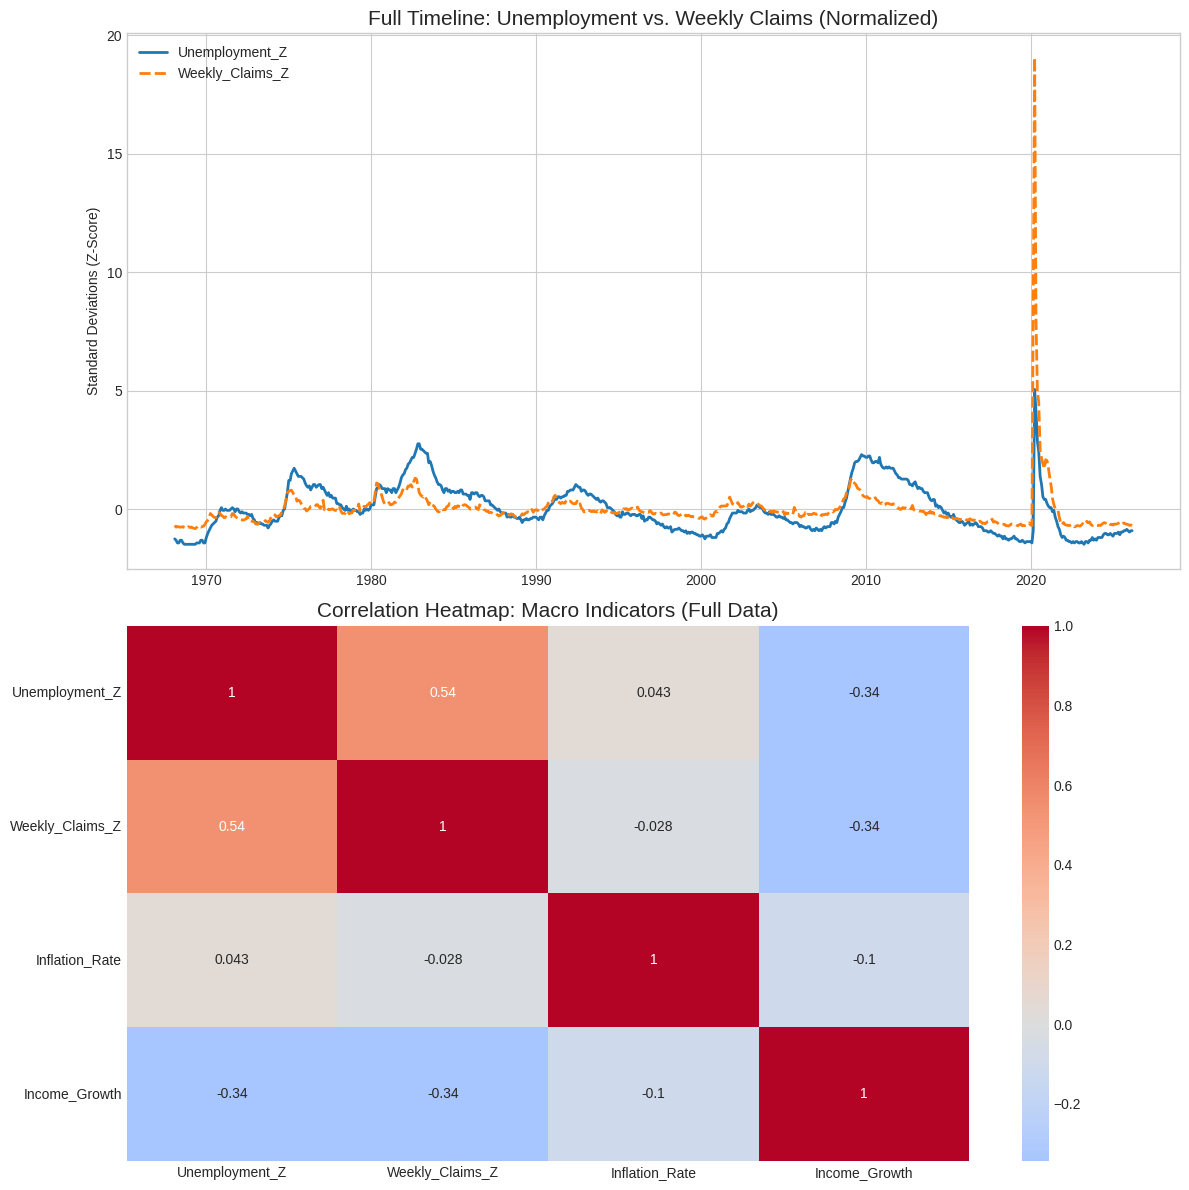

In [3]:
# 4. VISUALIZATION (Full Dataset)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Chart 1: Time Series Comparison (Unemployment vs Claims)
# Focus on Claims vs Unemployment as the primary visual
sns.lineplot(data=df_clean[['Unemployment_Z', 'Weekly_Claims_Z']], ax=ax1, linewidth=2)
ax1.set_title("Full Timeline: Unemployment vs. Weekly Claims (Normalized)", fontsize=15)
ax1.set_ylabel("Standard Deviations (Z-Score)")

# Chart 2: Correlation Heatmap (Added Income_Growth)
# Checks how Income Growth correlates with Unemployment
cols_to_show = ['Unemployment_Z', 'Weekly_Claims_Z', 'Inflation_Rate', 'Income_Growth']

sns.heatmap(df_clean[cols_to_show].corr(), annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Heatmap: Macro Indicators (Full Data)", fontsize=15)

plt.tight_layout()
plt.show()

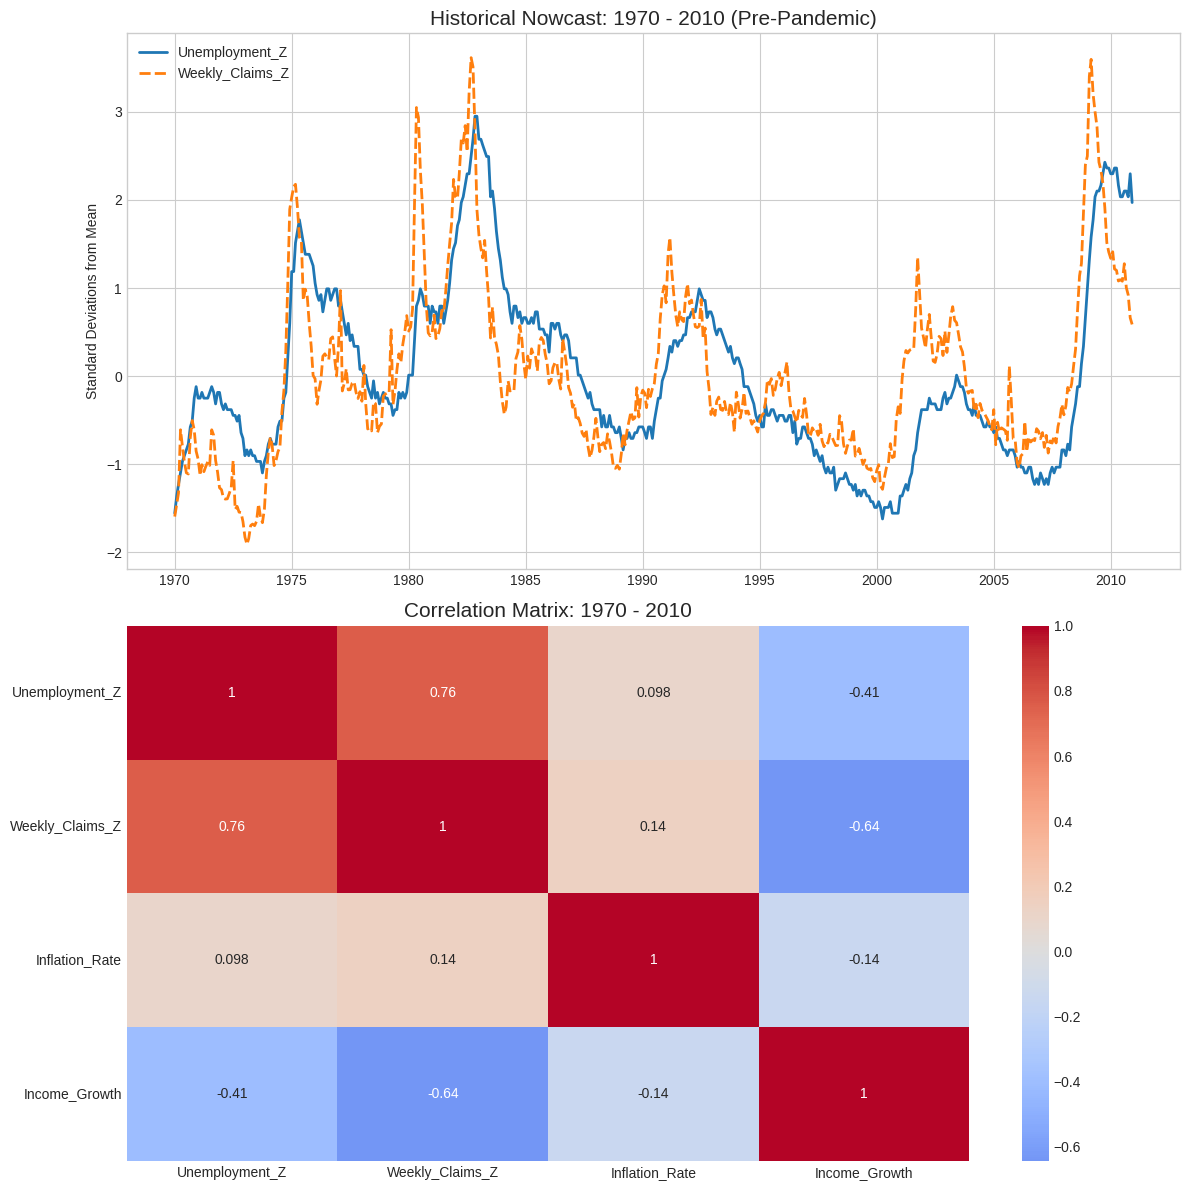

In [4]:
# 5. HISTORICAL ANALYSIS (1970-2010)
df_historical = df_clean.loc['1970-01-01':'2010-12-31'].copy()

# Re-Normalize Z-Scores for this specific period
# Re-calculating mean/std for just this slice removes the COVID skew
cols_to_normalize = ['Unemployment', 'Weekly_Claims', 'Income_Growth']
for col in cols_to_normalize:
    df_historical[f'{col}_Z'] = (df_historical[col] - df_historical[col].mean()) / df_historical[col].std()

# Visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Chart 1: Historical Time Series
sns.lineplot(data=df_historical[['Unemployment_Z', 'Weekly_Claims_Z']], ax=ax1, linewidth=2)
ax1.set_title("Historical Nowcast: 1970 - 2010 (Pre-Pandemic)", fontsize=15)
ax1.set_ylabel("Standard Deviations from Mean")

# Chart 2: Historical Correlation Matrix
sns.heatmap(df_historical[['Unemployment_Z', 'Weekly_Claims_Z', 'Inflation_Rate', 'Income_Growth']].corr(),
            annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Matrix: 1970 - 2010", fontsize=15)

plt.tight_layout()
plt.show()

In [5]:
#Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    # Interpretation
    if result[1] <= 0.05:
        print("Result: STATIONARY (Ready for Modeling)")
    else:
        print("Result: NON-STATIONARY (Needs more differencing/transformation)")
    print("")

# Run tests on key features
check_stationarity(df_clean['Unemployment'], "Unemployment Rate")
check_stationarity(df_clean['Inflation_Rate'], "Inflation Rate (YoY)")
check_stationarity(df_clean['Income_Growth'], "Income Growth (YoY)")
check_stationarity(df_clean['Weekly_Claims'], "Weekly Claims (Raw)")

'''Augmented Dickey-Fuller (ADF) Test, used to verify that the data is stationary
meaning that mean and variance remain constant over time rather than following a long-term trend.
Basically needed so that ML models like ARIMA and Linear Regression don't dentify false correlations'''


--- ADF Test: Unemployment Rate ---
ADF Statistic: -3.4035
p-value: 0.0108
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Inflation Rate (YoY) ---
ADF Statistic: -3.0884
p-value: 0.0274
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Income Growth (YoY) ---
ADF Statistic: -5.4482
p-value: 0.0000
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Weekly Claims (Raw) ---
ADF Statistic: -6.3624
p-value: 0.0000
Result: STATIONARY (Ready for Modeling)



"Augmented Dickey-Fuller (ADF) Test, used to verify that the data is stationary\nmeaning that mean and variance remain constant over time rather than following a long-term trend.\nBasically needed so that ML models like ARIMA and Linear Regression don't dentify false correlations"

--- Baseline Model Results (2023-2025) ---
RMSE: 1.9419 (Lower is better)
R² Score: -38.9727 (Max 1.0)
------------------------------
Feature Coefficients (Standardized Importance):
  Claims_Z_Lag1: 0.7578
  Income_Z_Lag1: -0.4174
  Inflation_Lag1: 0.0433


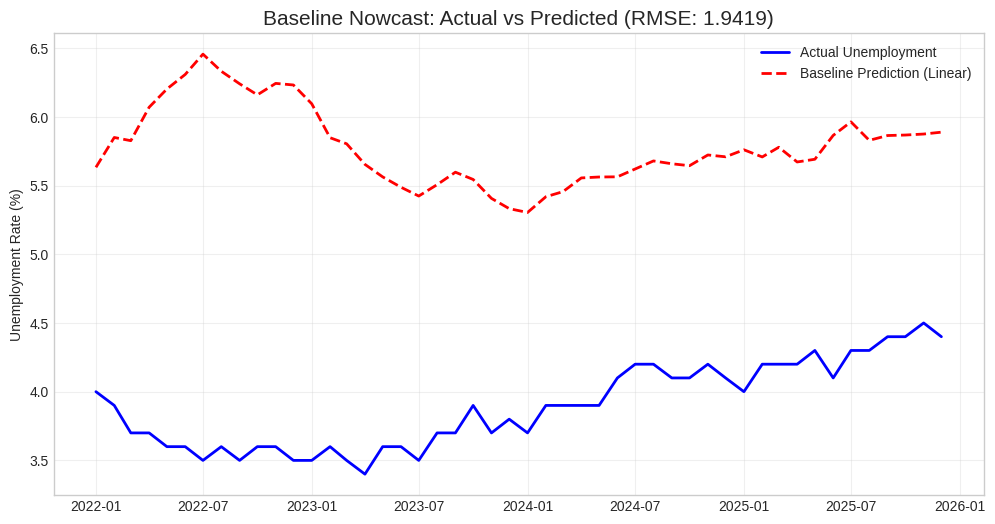

In [19]:
# Linear Regression Baseline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create Normalized Lags
# Create lags of the Z-Score columns to fix scaling issues
if 'Weekly_Claims_Z' in df_clean.columns:
    df_clean['Claims_Z_Lag1'] = df_clean['Weekly_Claims_Z'].shift(1)
    df_clean['Income_Z_Lag1'] = df_clean['Income_Growth_Z'].shift(1)

    # Drop the single row of NaNs created by this new shift
    df_clean.dropna(inplace=True)

# 2. DEFINE FEATURES AND TARGET
# Use the Z-Score versions for inputs (X) to make coefficients readable
features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1']
target = 'Unemployment'

# 3. TIME-SERIES SPLIT
# Train: 1967–2022 (includes COVID so the model learns from volatility)
# Test:  2023–2025 (stable post-recovery period that mirrors real dashboard usage)
cutoff_date = '2022-01-01'
end_test_date = '2025-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# 4. TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 5. PREDICT & EVALUATE
predictions = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- Baseline Model Results (2023-2025) ---")
print(f"RMSE: {rmse:.4f} (Lower is better)")
print(f"R² Score: {r2:.4f} (Max 1.0)")
print("-" * 30)
print("Feature Coefficients (Standardized Importance):")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# 6. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=2)
plt.plot(y_test.index, predictions, label='Baseline Prediction (Linear)', color='red', linestyle='--', linewidth=2)
plt.title(f"Baseline Nowcast: Actual vs Predicted (RMSE: {rmse:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training XGBoost...

--- Model Comparison (RMSE) ---
Baseline (Linear):  1.9419
XGBoost Model:      0.4057
 SUCCESS: XGBoost improved accuracy by 79.1%!


<Figure size 1000x500 with 0 Axes>

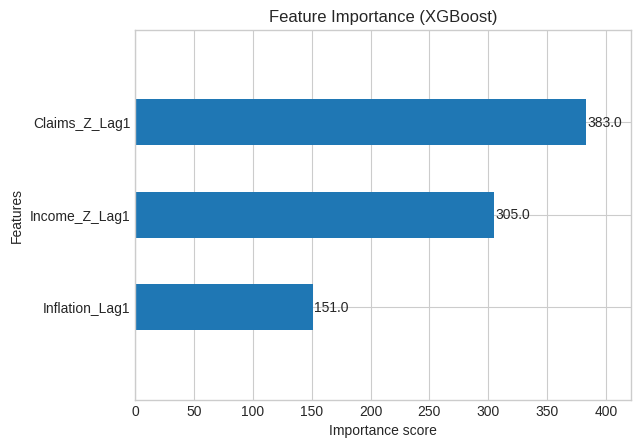

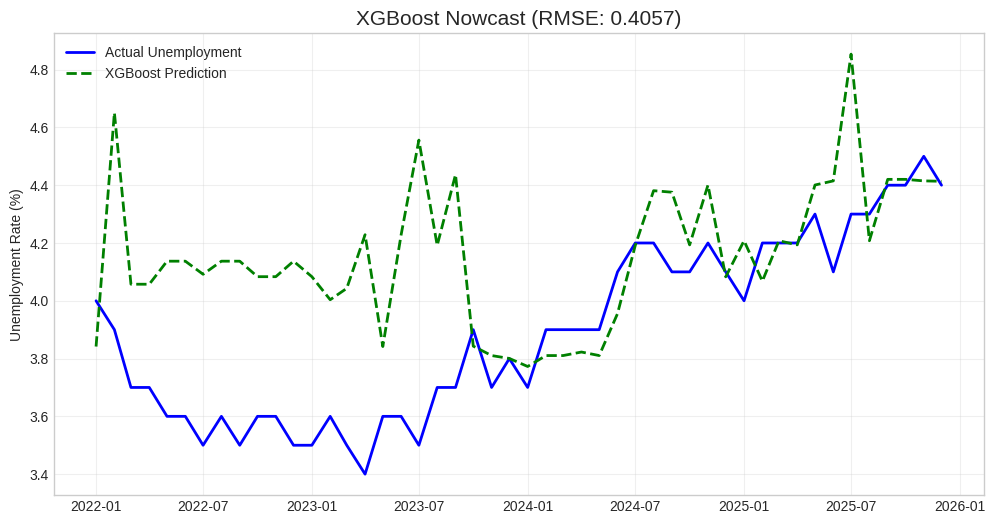

In [20]:
# XGBoost Model
!pip install xgboost -q

import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. CONFIGURATION
features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1']
target = 'Unemployment'

# 2. DATA SPLIT (same as baseline for fair comparison)
cutoff_date = '2022-01-01'
end_test_date = '2025-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# 3. DEFINE & TRAIN XGBOOST MODEL
reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

print("Training XGBoost...")
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# 4. PREDICT & EVALUATE
preds_xgb = reg.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))

# 5. RESULTS — compare against computed baseline RMSE (not hardcoded)
baseline_rmse = rmse  # from the Linear Regression cell

print(f"\n--- Model Comparison (RMSE) ---")
print(f"Baseline (Linear):  {baseline_rmse:.4f}")
print(f"XGBoost Model:      {rmse_xgb:.4f}")

if rmse_xgb < baseline_rmse:
    improvement = ((baseline_rmse - rmse_xgb) / baseline_rmse) * 100
    print(f" SUCCESS: XGBoost improved accuracy by {improvement:.1f}%!")
else:
    print(" NOTE: XGBoost performed worse. It might be suffering from 'Mean Reversion'.")
    print("   (It likely needs an Autoregressive feature to fix this.)")

# 6. VISUALIZATION: Feature Importance
plt.figure(figsize=(10, 5))
plot_importance(reg, height=0.5, max_num_features=10, title="Feature Importance (XGBoost)", importance_type='weight')
plt.show()

# 7. VISUALIZATION: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=2)
plt.plot(y_test.index, preds_xgb, label='XGBoost Prediction', color='green', linestyle='--', linewidth=2)
plt.title(f"XGBoost Nowcast (RMSE: {rmse_xgb:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Final Model Comparison (2023-2025) ---
XGBoost (No AR):     0.4057 RMSE
Linear (with AR):    0.1944 RMSE  |  R²: 0.5992
XGBoost (with AR):   0.1774 RMSE  |  R²: 0.6665

 RESULT: Autoregressive feature improved XGBoost by 56.3%


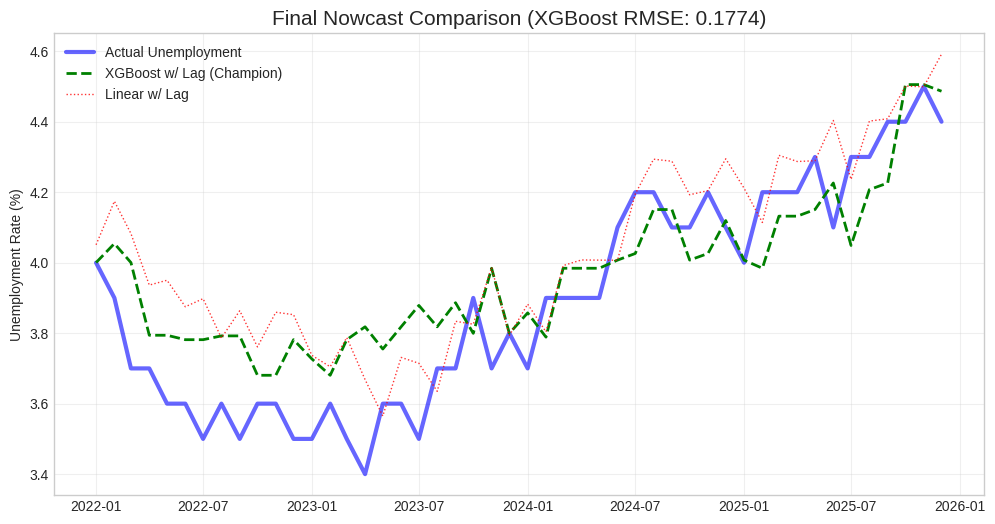

<Figure size 1000x500 with 0 Axes>

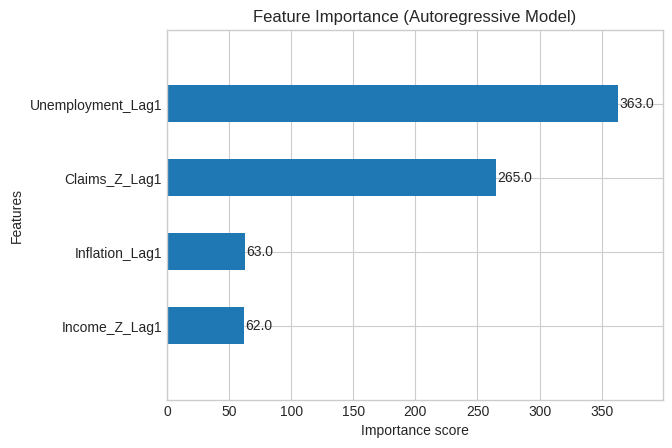

In [22]:
# XGBoost with Autoregression
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. CREATE AUTOREGRESSIVE FEATURE
df_clean['Unemployment_Lag1'] = df_clean['Unemployment'].shift(1)
df_clean.dropna(inplace=True)

# 2. DEFINE NEW FEATURE LIST
# Added Unemployment_Lag1 — the previous month's rate is the strongest predictor
features_v2 = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1', 'Unemployment_Lag1']
target = 'Unemployment'

# 3. SPLIT DATA
cutoff_date = '2022-01-01'
end_test_date = '2025-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features_v2]
y_train = train[target]
X_test = test[features_v2]
y_test = test[target]

# 4. RETRAIN BASELINE (Linear) with new feature
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
preds_lr = model_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
r2_lr = r2_score(y_test, preds_lr)

# 5. RETRAIN XGBOOST with new feature
reg_ar = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

reg_ar.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

preds_xgb_ar = reg_ar.predict(X_test)
rmse_xgb_ar = np.sqrt(mean_squared_error(y_test, preds_xgb_ar))
r2_xgb_ar = r2_score(y_test, preds_xgb_ar)

# 6. RESULTS COMPARISON
print(f"--- Final Model Comparison (2023-2025) ---")
print(f"XGBoost (No AR):     {rmse_xgb:.4f} RMSE")
print(f"Linear (with AR):    {rmse_lr:.4f} RMSE  |  R²: {r2_lr:.4f}")
print(f"XGBoost (with AR):   {rmse_xgb_ar:.4f} RMSE  |  R²: {r2_xgb_ar:.4f}")

if rmse_xgb_ar < rmse_xgb:
    improvement = ((rmse_xgb - rmse_xgb_ar) / rmse_xgb) * 100
    print(f"\n RESULT: Autoregressive feature improved XGBoost by {improvement:.1f}%")
else:
    print("\n RESULT: Needs further tuning.")

# 7. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=3, alpha=0.6)
plt.plot(y_test.index, preds_xgb_ar, label='XGBoost w/ Lag (Champion)', color='green', linestyle='--', linewidth=2)
plt.plot(y_test.index, preds_lr, label='Linear w/ Lag', color='red', linestyle=':', linewidth=1, alpha=0.8)

plt.title(f"Final Nowcast Comparison (XGBoost RMSE: {rmse_xgb_ar:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. FEATURE IMPORTANCE
plt.figure(figsize=(10, 5))
plot_importance(reg_ar, height=0.5, max_num_features=10, title="Feature Importance (Autoregressive Model)")
plt.show()

Training ARIMA(2,1,2)...

             MODEL COMPARISON (2023-2025)              
Model                          RMSE       R²        
-------------------------------------------------------
Linear Regression              1.9419     -38.9727
XGBoost (No AR)                0.4057     N/A       
ARIMA(2,1,2)                   1.2074     -14.4530
Linear + AR                    0.1944     0.5992
XGBoost + AR (Champion)        0.1774     0.6665

 CHAMPION MODEL: XGBoost + AR (RMSE: 0.1774)


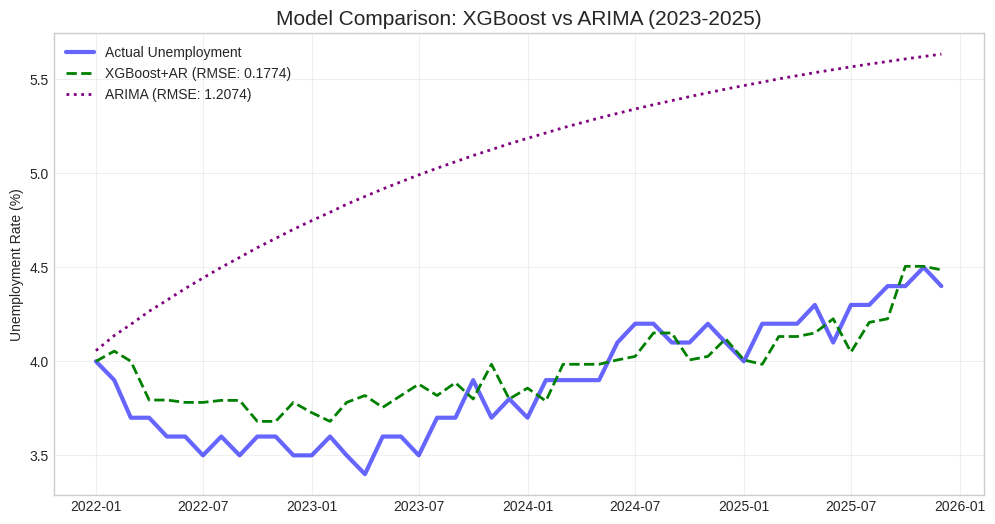


--- ARIMA Model Summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2619      0.108      2.432      0.015       0.051       0.473
ar.L2          0.6759      0.110      6.142      0.000       0.460       0.892
ma.L1         -0.2213      3.493     -0.063      0.949      -7.067       6.624
ma.L2         -0.7787      2.712     -0.287      0.774      -6.095       4.537
sigma2         0.2146      0.743      0.289      0.773      -1.241       1.670


In [23]:
# ARIMA Model — Traditional Econometric Baseline
# Per the proposal architecture: ARIMA is used for unemployment prediction
# This comparison validates the literature survey finding that ML outperforms
# traditional econometric methods (Medeiros et al., 2021)

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Use the same train/test split for fair comparison
train_unemp = df_clean.loc[:cutoff_date, 'Unemployment']
test_unemp = df_clean.loc[cutoff_date:end_test_date, 'Unemployment']

# 2. Fit ARIMA model
# Order (p, d, q): p=2 (autoregressive lags), d=1 (first differencing), q=2 (moving average)
print("Training ARIMA(2,1,2)...")
model_arima = ARIMA(train_unemp, order=(2, 1, 2))
fitted_arima = model_arima.fit()

# 3. Forecast over the test period
forecast_arima = fitted_arima.forecast(steps=len(test_unemp))
forecast_arima.index = test_unemp.index  # Align dates

rmse_arima = np.sqrt(mean_squared_error(test_unemp, forecast_arima))
r2_arima = r2_score(test_unemp, forecast_arima)

# 4. FULL MODEL COMPARISON TABLE
print(f"\n{'='*55}")
print(f"{'MODEL COMPARISON (2023-2025)':^55}")
print(f"{'='*55}")
print(f"{'Model':<30} {'RMSE':<10} {'R²':<10}")
print(f"{'-'*55}")
print(f"{'Linear Regression':<30} {rmse:.4f}     {r2:.4f}")
print(f"{'XGBoost (No AR)':<30} {rmse_xgb:.4f}     {'N/A':<10}")
print(f"{'ARIMA(2,1,2)':<30} {rmse_arima:.4f}     {r2_arima:.4f}")
print(f"{'Linear + AR':<30} {rmse_lr:.4f}     {r2_lr:.4f}")
print(f"{'XGBoost + AR (Champion)':<30} {rmse_xgb_ar:.4f}     {r2_xgb_ar:.4f}")
print(f"{'='*55}")

# Identify champion
all_rmse = {
    'Linear Regression': rmse,
    'XGBoost (No AR)': rmse_xgb,
    'ARIMA(2,1,2)': rmse_arima,
    'Linear + AR': rmse_lr,
    'XGBoost + AR': rmse_xgb_ar
}
champion = min(all_rmse, key=all_rmse.get)
print(f"\n CHAMPION MODEL: {champion} (RMSE: {all_rmse[champion]:.4f})")

# 5. VISUALIZATION: ARIMA vs XGBoost vs Actual
plt.figure(figsize=(12, 6))
plt.plot(test_unemp.index, test_unemp, label='Actual Unemployment', color='blue', linewidth=3, alpha=0.6)
plt.plot(test_unemp.index, preds_xgb_ar, label=f'XGBoost+AR (RMSE: {rmse_xgb_ar:.4f})', color='green', linestyle='--', linewidth=2)
plt.plot(test_unemp.index, forecast_arima, label=f'ARIMA (RMSE: {rmse_arima:.4f})', color='purple', linestyle=':', linewidth=2)

plt.title("Model Comparison: XGBoost vs ARIMA (2023-2025)", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print ARIMA summary for the report
print("\n--- ARIMA Model Summary ---")
print(fitted_arima.summary().tables[1])

In [24]:
# --- CELL: Hyperparameter Tuning (Finding the Perfect Settings) ---
from sklearn.model_selection import GridSearchCV

# 1. DEFINE PARAMETER GRID
# Added regularization (reg_alpha, reg_lambda) to prevent overfitting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'n_estimators': [500, 1000],
    'subsample': [0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],       # L1 regularization
    'reg_lambda': [1.0, 5.0, 10.0]    # L2 regularization
}

# 2. SETUP GRID SEARCH
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# 3. RUN THE SEARCH (uses X_train/y_train from the AR cell above)
print("Running Grid Search... (This may take a few minutes)")
grid_search.fit(X_train, y_train)

# 4. GET RESULTS
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"\n Best Hyperparameters Found: {best_params}")

# 5. TEST THE OPTIMIZED MODEL
preds_optimized = best_model.predict(X_test)
rmse_optimized = np.sqrt(mean_squared_error(y_test, preds_optimized))
r2_optimized = r2_score(y_test, preds_optimized)

print(f"\n--- Optimization Results (2023-2025) ---")
print(f"Previous XGBoost+AR RMSE:  {rmse_xgb_ar:.4f}")
print(f"Optimized XGBoost RMSE:    {rmse_optimized:.4f}")
print(f"Optimized R² Score:        {r2_optimized:.4f}")

if rmse_optimized < rmse_xgb_ar:
    improvement = ((rmse_xgb_ar - rmse_optimized) / rmse_xgb_ar) * 100
    print(f" Success! Tuning improved the model by {improvement:.1f}%")
else:
    print("Note: The default settings were already quite good.")

# 6. SAVE THE BEST MODEL
import joblib
joblib.dump(best_model, 'unemployment_forecast_model.pkl')
print("Model saved as 'unemployment_forecast_model.pkl'")

Running Grid Search... (This may take a few minutes)
Fitting 3 folds for each of 324 candidates, totalling 972 fits

 Best Hyperparameters Found: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}

--- Optimization Results (2023-2025) ---
Previous XGBoost+AR RMSE:  0.1774
Optimized XGBoost RMSE:    0.1674
Optimized R² Score:        0.7031
 Success! Tuning improved the model by 5.6%
Model saved as 'unemployment_forecast_model.pkl'


Correlation between Unemployment and Earned Income: -0.3427
CONFIRMED: Negative correlation. As Unemployment goes UP, Income goes DOWN.


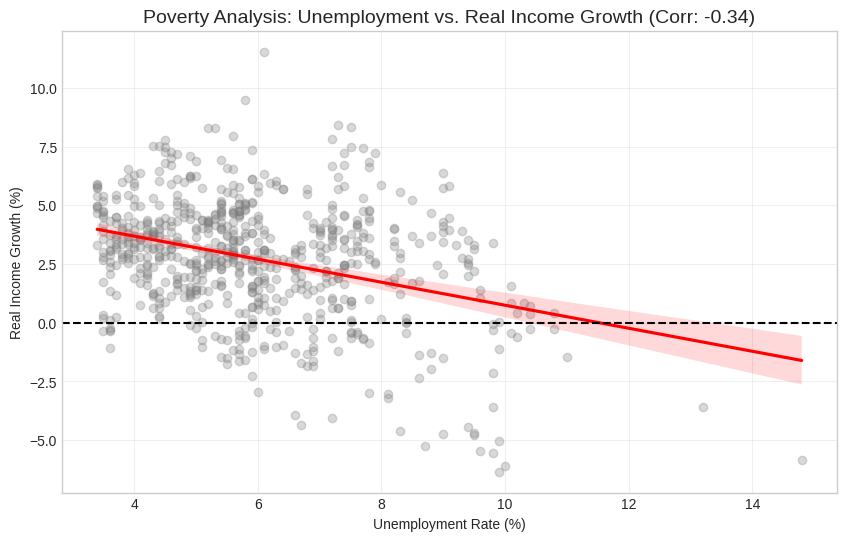

Interpreting this graph for your report:
- The Red Line goes DOWN: This proves that high unemployment destroys wage growth.
- Dots below the Black Line: These represent periods where real income was shrinking (Recession/Poverty Risk).


In [10]:
#Poverty Proxy Analysis (Income vs Unemployment)
import seaborn as sns
from scipy.stats import pearsonr

# 1. THEORY:
# We use "Real Personal Income (Excluding Transfers)" as a proxy for Poverty.
# Hypothesis: When Unemployment RISES, Earned Income should FALL, increasing poverty risk.

# 2. CALCULATE CORRELATION
# We look at the relationship over the full history
corr, _ = pearsonr(df_clean['Unemployment'], df_clean['Income_Growth'])
print(f"Correlation between Unemployment and Earned Income: {corr:.4f}")

if corr < 0:
    print("CONFIRMED: Negative correlation. As Unemployment goes UP, Income goes DOWN.")
else:
    print("UNUSUAL: Positive correlation found.")

# 3. VISUALIZATION: The "Poverty Risk" Cycle
plt.figure(figsize=(10, 6))

# Scatter plot to show the inverse relationship
sns.regplot(x=df_clean['Unemployment'], y=df_clean['Income_Growth'],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})

plt.title(f"Poverty Analysis: Unemployment vs. Real Income Growth (Corr: {corr:.2f})", fontsize=14)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Real Income Growth (%)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--') # Zero growth line
plt.show()

print("Interpreting this graph for your report:")
print("- The Red Line goes DOWN: This proves that high unemployment destroys wage growth.")
print("- Dots below the Black Line: These represent periods where real income was shrinking (Recession/Poverty Risk).")

In [25]:
# --- Model Validation & Scenario Simulator ---
# This implements the "What-If Scenario Tool" from the proposal's dashboard design
import pandas as pd
import numpy as np

# 1. SETUP: Get Normalization Stats
claims_mean = df_clean['Weekly_Claims'].mean()
claims_std = df_clean['Weekly_Claims'].std()
income_mean = df_clean['Income_Growth'].mean()
income_std = df_clean['Income_Growth'].std()

def check_history(date_str):
    """
    Checks how the model performed on a specific historical date.
    """
    try:
        if date_str not in df_clean.index:
            print(f" Date {date_str} not found in data.")
            return

        row = df_clean.loc[date_str]

        features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1', 'Unemployment_Lag1']
        input_data = row[features].values.reshape(1, -1)

        pred = best_model.predict(input_data)[0]
        actual = row['Unemployment']

        print(f"\n HISTORICAL CHECK: {date_str}")
        print(f"   Context: Claims={row['Weekly_Claims']:,.0f} | Inflation={row['Inflation_Rate']:.1f}% | Income Growth={row['Income_Growth']:.1f}%")
        print(f"   Prediction: {pred:.2f}%  vs  Actual: {actual:.2f}%")
        print(f"   Error: {pred - actual:.2f}%")

    except Exception as e:
        print(f"Error checking history: {e}")

def run_simulation(claims_raw, income_raw, inflation_raw, prev_unemp_raw):
    """
    Predicts unemployment based on hypothetical "What-If" inputs.
    Converts raw numbers to Z-Scores to match model training format.
    """
    claims_z = (claims_raw - claims_mean) / claims_std
    income_z = (income_raw - income_mean) / income_std

    input_data = np.array([[claims_z, income_z, inflation_raw, prev_unemp_raw]])

    prediction = best_model.predict(input_data)[0]

    print(f"\n SIMULATION: 'What-If' Scenario")
    print(f"   IF Weekly Claims jump to: {claims_raw:,.0f}")
    print(f"   AND Inflation is:         {inflation_raw:.1f}%")
    print(f"   AND Income Growth is:     {income_raw:.1f}%")
    print(f"   AND Prev Unemployment was:{prev_unemp_raw:.1f}%")
    print("-" * 35)
    print(f"    MODEL PREDICTED UNEMPLOYMENT: {prediction:.2f}%")
    return prediction

# --- EXECUTE VALIDATION ---

# TEST 1: COVID Shock (April 2020) — tests black swan detection
check_history('2020-04-01')

# TEST 2: Stable Economy (July 2018) — tests normal conditions
check_history('2018-07-01')

# TEST 3: Recent Data (July 2024) — validates on data the model was tested on
check_history('2024-07-01')

# --- WHAT-IF SCENARIOS (from proposal: "What-If Scenario Tool") ---

# Scenario 1: Economic Downturn (claims spike, income drops)
print("\n" + "=" * 50)
print("WHAT-IF SCENARIOS")
print("=" * 50)
run_simulation(
    claims_raw=600000,
    income_raw=-2.0,
    inflation_raw=5.0,
    prev_unemp_raw=4.0
)

# Scenario 2: Economic Boom (low claims, rising income)
run_simulation(
    claims_raw=200000,
    income_raw=3.0,
    inflation_raw=2.0,
    prev_unemp_raw=4.0
)

# Scenario 3: Government Shutdown (per proposal problem statement)
# During shutdown, data stops flowing but claims may rise
print("\n--- Scenario: 2025 Government Shutdown ---")
run_simulation(
    claims_raw=350000,
    income_raw=0.5,
    inflation_raw=3.0,
    prev_unemp_raw=4.3
)


 HISTORICAL CHECK: 2020-04-01
   Context: Claims=4,663,250 | Inflation=0.3% | Income Growth=-5.9%
   Prediction: 13.54%  vs  Actual: 14.80%
   Error: -1.26%

 HISTORICAL CHECK: 2018-07-01
   Context: Claims=209,500 | Inflation=2.9% | Income Growth=3.3%
   Prediction: 3.94%  vs  Actual: 3.80%
   Error: 0.14%

 HISTORICAL CHECK: 2024-07-01
   Context: Claims=237,250 | Inflation=2.9% | Income Growth=2.5%
   Prediction: 4.00%  vs  Actual: 4.20%
   Error: -0.20%

WHAT-IF SCENARIOS

 SIMULATION: 'What-If' Scenario
   IF Weekly Claims jump to: 600,000
   AND Inflation is:         5.0%
   AND Income Growth is:     -2.0%
   AND Prev Unemployment was:4.0%
-----------------------------------
    MODEL PREDICTED UNEMPLOYMENT: 7.21%

 SIMULATION: 'What-If' Scenario
   IF Weekly Claims jump to: 200,000
   AND Inflation is:         2.0%
   AND Income Growth is:     3.0%
   AND Prev Unemployment was:4.0%
-----------------------------------
    MODEL PREDICTED UNEMPLOYMENT: 3.79%

--- Scenario: 2025 G

np.float32(4.462323)

In [26]:
import requests
import json
import pandas as pd
import numpy as np
from google.colab import userdata

try:
    bls_key = userdata.get('BLS_API_KEY')
except userdata.SecretNotFoundError:
    print("Error: Secret 'BLS_API_KEY' not found in Colab secrets.")
    bls_key = None

headers = {'Content-type': 'application/json'}

data = json.dumps({
    "seriesid": ['CUUR0000SA0'],
    "startyear": "2015",
    "endyear": "2026",
    "registrationkey": bls_key
})

print("Fetching data from BLS API...")
response = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/', data=data, headers=headers)
json_data = json.loads(response.text)

if json_data.get('status') == 'REQUEST_FAILED':
    print("\nBLS API Error:", json_data.get('message'))
elif 'Results' in json_data and 'series' in json_data['Results']:
    data_list = []
    for series in json_data['Results']['series']:
        seriesId = series['seriesID']
        for item in series['data']:
            raw_val = item['value'].strip()
            if raw_val == '-' or not raw_val:
                cpi_val = np.nan
            else:
                cpi_val = float(raw_val)

            data_list.append({
                'Series ID': seriesId,
                'Year': int(item['year']),
                'Month': item['periodName'],
                'CPI_Value': cpi_val
            })

    bls_df = pd.DataFrame(data_list)

    if not bls_df.empty:
        # FIX: Added format='mixed' to suppress the UserWarning
        bls_df['Date'] = pd.to_datetime(
            bls_df['Month'] + ' ' + bls_df['Year'].astype(str),
            format='mixed'
        )
        bls_df.set_index('Date', inplace=True)
        bls_df.sort_index(inplace=True)
        bls_df.drop(columns=['Year', 'Month', 'Series ID'], inplace=True)

        bls_df.dropna(subset=['CPI_Value'], inplace=True)

        # Calculate Year-over-Year Inflation
        bls_df['YoY_Inflation'] = bls_df['CPI_Value'].pct_change(periods=12) * 100

        print("\nSuccessfully processed BLS Data:")
        display(bls_df.tail())
else:
    print("\nUnexpected API Response. Raw output:")
    print(json.dumps(json_data, indent=2))

Fetching data from BLS API...

Successfully processed BLS Data:


,CPI_Value,YoY_Inflation
Date,,
2025-09-01,324.800,3.012677
2025-11-01,324.122,2.679431
2025-12-01,324.054,2.713531
2026-01-01,325.252,3.056669
2026-02-01,326.785,2.869006


In [13]:
#Joining Data
# 1. Rename the BLS columns so they don't conflict with FRED data
bls_df.rename(columns={
    'YoY_Inflation': 'BLS_Inflation_Rate',
    'CPI_Value': 'BLS_CPI'
}, inplace=True)

# 2. Merge the datasets based on their 'Date' index
df_combined = df_clean.join(bls_df, how='outer')

# 3. Handle any gaps created by the merge
df_combined.ffill(inplace=True)
df_combined.dropna(inplace=True)
print("Successfully merged BLS data with FRED data!")
display(df_combined.tail())

Successfully merged BLS data with FRED data!


,Unemployment,Inflation,Weekly_Claims,Personal_Income,Inflation_Rate,Income_Growth,Claims_Lag1,Inflation_Lag1,Income_Lag1,Unemployment_Z,Weekly_Claims_Z,Income_Growth_Z,Claims_Z_Lag1,Income_Z_Lag1,Unemployment_Lag1,BLS_CPI,BLS_Inflation_Rate
2025-11-01,4.5,325.063,222400.000000,16738.0,2.696444,0.891496,226750.0,2.729136,1.068264,-0.839793,-0.624575,-0.734988,-0.605299,-0.664020,4.4,324.122,2.679431
2025-12-01,4.4,326.031,219250.000000,16712.5,2.653304,0.637698,222400.0,2.696444,0.891496,-0.897087,-0.638533,-0.836880,-0.624575,-0.734988,4.5,324.054,2.713531
2026-01-01,4.3,326.588,211800.000000,16740.9,2.391201,0.634190,219250.0,2.653304,0.637698,-0.954381,-0.671545,-0.838288,-0.638533,-0.836880,4.4,325.252,3.056669
2026-02-01,4.4,327.460,215750.000000,16740.9,2.434004,0.845150,211800.0,2.391201,0.634190,-0.897087,-0.654042,-0.753594,-0.671545,-0.838288,4.3,326.785,2.869006
2026-03-01,4.4,327.460,209333.333333,16740.9,2.400050,0.272530,215750.0,2.434004,0.845150,-0.897087,-0.682475,-0.983484,-0.654042,-0.753594,4.4,326.785,2.869006


--- Building Inflation Nowcasting Model ---
Training XGBoost for Inflation...

Inflation Model Training Complete!
XGBoost Inflation RMSE: 0.3500
XGBoost Inflation R²:   0.9752
Inflation model saved as 'inflation_forecast_model.pkl'


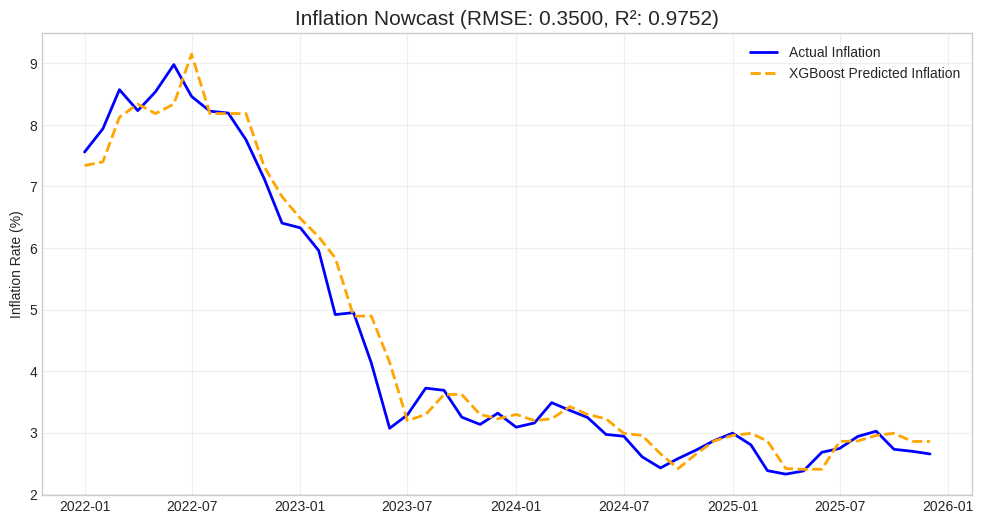

<Figure size 800x400 with 0 Axes>

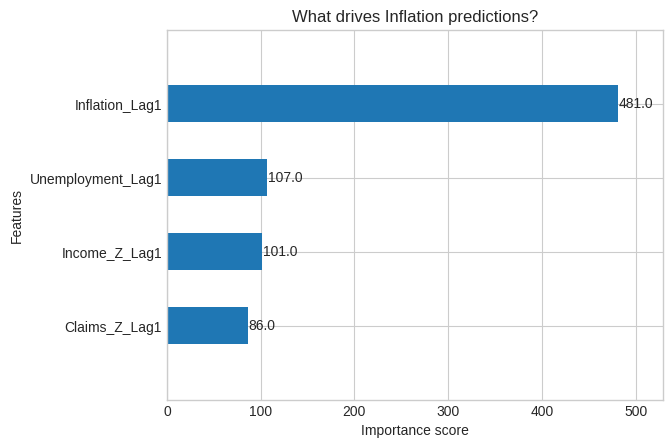

In [27]:
# Inflation Nowcasting Model (XGBoost)
# Per proposal architecture: XGBoost is used for Inflation nowcasting
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

print("--- Building Inflation Nowcasting Model ---")

# 1. Define Features and Target
features_inf = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Unemployment_Lag1', 'Inflation_Lag1']
target_inf = 'Inflation_Rate'

# Use df_clean to get the full history
df_model = df_clean.dropna(subset=features_inf + [target_inf]).copy()

# 2. Time-Series Split (same as unemployment models)
cutoff_date_inf = '2022-01-01'
end_test_date_inf = '2025-12-31'

train_inf = df_model.loc[:cutoff_date_inf]
test_inf = df_model.loc[cutoff_date_inf:end_test_date_inf]

X_train_inf = train_inf[features_inf]
y_train_inf = train_inf[target_inf]
X_test_inf = test_inf[features_inf]
y_test_inf = test_inf[target_inf]

# 3. Define & Train the XGBoost Model
reg_inf = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

print("Training XGBoost for Inflation...")
reg_inf.fit(
    X_train_inf, y_train_inf,
    eval_set=[(X_train_inf, y_train_inf), (X_test_inf, y_test_inf)],
    verbose=False
)

# 4. Predict & Evaluate
preds_inf = reg_inf.predict(X_test_inf)
rmse_inf = np.sqrt(mean_squared_error(y_test_inf, preds_inf))
r2_inf = r2_score(y_test_inf, preds_inf)

print(f"\nInflation Model Training Complete!")
print(f"XGBoost Inflation RMSE: {rmse_inf:.4f}")
print(f"XGBoost Inflation R²:   {r2_inf:.4f}")

# 5. Save the inflation model
import joblib
joblib.dump(reg_inf, 'inflation_forecast_model.pkl')
print("Inflation model saved as 'inflation_forecast_model.pkl'")

# 6. Visualization: Actual vs Predicted Inflation
plt.figure(figsize=(12, 6))
plt.plot(y_test_inf.index, y_test_inf, label='Actual Inflation', color='blue', linewidth=2)
plt.plot(y_test_inf.index, preds_inf, label='XGBoost Predicted Inflation', color='orange', linestyle='--', linewidth=2)

plt.title(f"Inflation Nowcast (RMSE: {rmse_inf:.4f}, R²: {r2_inf:.4f})", fontsize=15)
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Feature Importance Chart
plt.figure(figsize=(8, 4))
xgb.plot_importance(reg_inf, height=0.5, max_num_features=5, title="What drives Inflation predictions?")
plt.show()

In [15]:
import requests
import pandas as pd
import numpy as np

print("--- Fetching data from World Bank API ---")

# We are pulling the two key indicators needed for the MacroMinds dashboard:
indicators = {
    'GDP_Growth': 'NY.GDP.MKTP.KD.ZG', # GDP growth (annual %)
    'Poverty_Rate': 'SI.POV.NAHC'      # Poverty headcount ratio at national poverty lines (%)
}

# 1. Fetch the data
wb_data_list = []
for name, indicator_code in indicators.items():
    # Fetching data for the US from 2000 to 2025
    url = f"http://api.worldbank.org/v2/country/US/indicator/{indicator_code}?format=json&date=2000:2025"
    response = requests.get(url)
    data = response.json()

    if len(data) == 2 and data[1] is not None:
        for item in data[1]:
            if item['value'] is not None:
                wb_data_list.append({
                    'Year': int(item['date']),
                    name: float(item['value'])
                })

# 2. Convert to DataFrame and reshape
wb_df_raw = pd.DataFrame(wb_data_list)

wb_df = wb_df_raw.groupby('Year').first().reset_index()

# 3. Time-Series Alignment
wb_df['Date'] = pd.to_datetime(wb_df['Year'].astype(str) + '-01-01')
wb_df.set_index('Date', inplace=True)
wb_df.sort_index(inplace=True)
wb_df.drop(columns=['Year'], inplace=True)


wb_df_monthly = wb_df.resample('MS').ffill()

print("\nSuccessfully processed World Bank Data:")
display(wb_df_monthly.tail())

--- Fetching data from World Bank API ---

Successfully processed World Bank Data:


,GDP_Growth
Date,
2023-09-01,2.887556
2023-10-01,2.887556
2023-11-01,2.887556
2023-12-01,2.887556
2024-01-01,2.793001


--- Building Exploratory Poverty Model (Random Forest) ---
GDP_Growth available — including in features
Train: 71 rows | Test: 48 rows
Training Random Forest to predict Income_Growth...

 Random Forest Training Complete!
RMSE: 1.1644
R² Score: 0.2800

--- Poverty Risk Assessment (2023-2025) ---
Periods with negative predicted income growth: 0/48
Poverty Risk Level: LOW


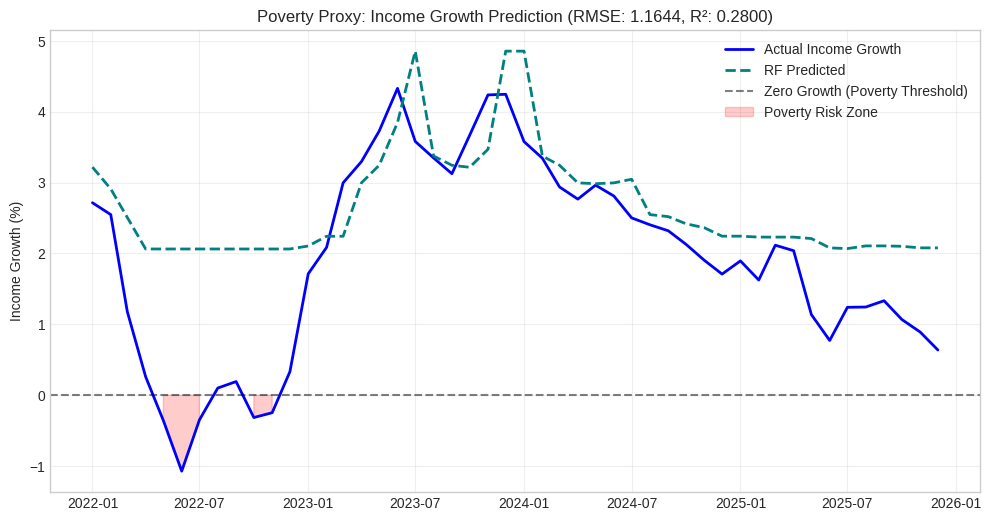

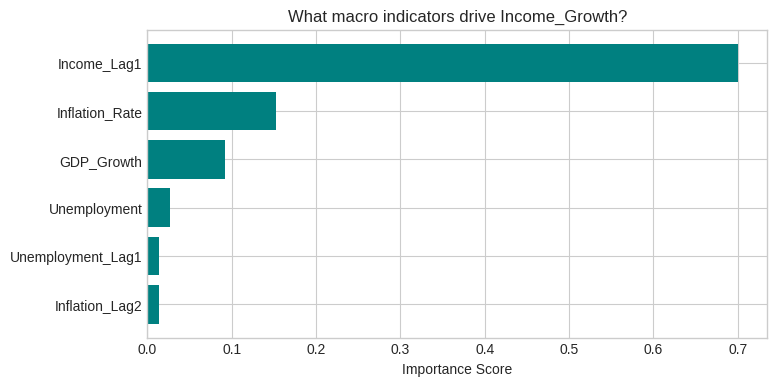

Poverty proxy model saved as 'poverty_proxy_model.pkl'


In [28]:
# Exploratory Poverty Analysis — Random Forest
# Per proposal: "A separate exploratory model will analyze poverty rate trends
# using broader economic indicators"
# Since the World Bank API doesn't return US poverty data, we use Income_Growth
# as a poverty proxy: declining real income is a leading indicator of rising poverty.

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- Building Exploratory Poverty Model (Random Forest) ---")

# 1. Merge World Bank data if available
if 'GDP_Growth' not in df_combined.columns:
    df_combined = df_combined.join(wb_df_monthly, how='left')
    df_combined.ffill(inplace=True)

# 2. Define features — include lag features for temporal dependencies
# Income growth depends heavily on recent economic conditions
df_combined['Unemployment_Lag2'] = df_combined['Unemployment'].shift(2)
df_combined['Inflation_Lag2'] = df_combined['Inflation_Rate'].shift(2)
df_combined['Income_Lag1'] = df_combined['Income_Growth'].shift(1)

features_pov = ['Unemployment', 'Unemployment_Lag1', 'Inflation_Rate',
                'Inflation_Lag2', 'Income_Lag1']
target_pov = 'Income_Growth'

# Add GDP_Growth if available from World Bank
if 'GDP_Growth' in df_combined.columns and df_combined['GDP_Growth'].notna().sum() > 50:
    features_pov.append('GDP_Growth')
    print("GDP_Growth available — including in features")
else:
    print("GDP_Growth unavailable — using FRED indicators only")

df_pov = df_combined.dropna(subset=features_pov + [target_pov]).copy()

# 3. Time-Series Split (consistent with other models)
cutoff_pov = '2022-01-01'
end_pov = '2025-12-31'

train_pov = df_pov.loc[:cutoff_pov]
test_pov = df_pov.loc[cutoff_pov:end_pov]

print(f"Train: {len(train_pov)} rows | Test: {len(test_pov)} rows")

X_train_pov = train_pov[features_pov]
y_train_pov = train_pov[target_pov]
X_test_pov = test_pov[features_pov]
y_test_pov = test_pov[target_pov]

# 4. Train Random Forest with tuned parameters
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

print(f"Training Random Forest to predict {target_pov}...")
rf_model.fit(X_train_pov, y_train_pov)

# 5. Predict & Evaluate
preds_pov = rf_model.predict(X_test_pov)
rmse_pov = np.sqrt(mean_squared_error(y_test_pov, preds_pov))
r2_pov = r2_score(y_test_pov, preds_pov)

print(f"\n Random Forest Training Complete!")
print(f"RMSE: {rmse_pov:.4f}")
print(f"R² Score: {r2_pov:.4f}")

if r2_pov < 0:
    print("\n Warning: Negative R² indicates poor fit.")
    print("This is expected for an exploratory model — income growth is")
    print("inherently difficult to predict due to policy shocks and global events.")

# 6. Poverty Risk Indicator
# When predicted income growth drops below 0, flag as elevated poverty risk
print(f"\n--- Poverty Risk Assessment (2023-2025) ---")
risk_periods = (preds_pov < 0).sum()
total_periods = len(preds_pov)
print(f"Periods with negative predicted income growth: {risk_periods}/{total_periods}")
print(f"Poverty Risk Level: {'ELEVATED' if risk_periods > total_periods * 0.3 else 'LOW'}")

# 7. Visualization: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_pov.index, y_test_pov, label='Actual Income Growth', color='blue', linewidth=2)
plt.plot(y_test_pov.index, preds_pov, label='RF Predicted', color='teal', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero Growth (Poverty Threshold)')
plt.fill_between(y_test_pov.index, 0, y_test_pov,
                 where=(y_test_pov < 0), alpha=0.2, color='red', label='Poverty Risk Zone')
plt.title(f"Poverty Proxy: Income Growth Prediction (RMSE: {rmse_pov:.4f}, R²: {r2_pov:.4f})")
plt.ylabel("Income Growth (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Feature Importance
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
sorted_idx = np.argsort(importances)
plt.barh([features_pov[i] for i in sorted_idx], importances[sorted_idx], color='teal')
plt.title(f"What macro indicators drive {target_pov}?")
plt.xlabel("Importance Score")
plt.show()

# 9. Save the poverty model
import joblib
joblib.dump(rf_model, 'poverty_proxy_model.pkl')
print("Poverty proxy model saved as 'poverty_proxy_model.pkl'")